# Boosted-tree tuning and calibration

Notebook 3 established `boosted_numeric` as the winner on all four chronological folds. This notebook tunes that family, keeps `context_C3` as an interpretable comparison model, tests calibration without temporal leakage, and inspects the newest-session failure slices. It does not export a production artifact.

In [1]:
from __future__ import annotations

import gc
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / 'README.md').exists() and (path / 'model').exists()),
    cwd,
)
CACHE_ROOT = PROJECT_ROOT / 'artifacts' / 'feature-search-cache'
ROWS_PER_SESSION = 300_000
CACHE_VERSION = 4
TRAIN_ROWS_PER_FOLD = 2_000_000
SESSION_ORDER = ['20229', '20235', '20239', '20245', '20249', '20255', '20259', '20265']
VALIDATION_SESSIONS = ['20239', '20249', '20259', '20265']
RANDOM_STATE = 42

cache_paths = {s: CACHE_ROOT / f'{s}-{ROWS_PER_SESSION}-v{CACHE_VERSION}.pkl' for s in SESSION_ORDER}
missing = [str(path) for path in cache_paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError('Run Notebook 1 to build the canonical cache. Missing: ' + ', '.join(missing))
session_samples = {session: pd.read_pickle(path) for session, path in cache_paths.items()}
print(f'Loaded {sum(map(len, session_samples.values())):,} cached rows')

Loaded 2,379,974 cached rows


## 1. Candidate specification

The boosted candidates vary tree size, learning rate, and L2 regularization around Notebook 3's winning configuration. `logistic_C3` is included as a control, not as the presumed production model. Every learned candidate uses the same deterministic training sample within a fold.

In [2]:
ALL_NUMERIC = [
    'position_to_capacity', 'waitlist_to_capacity', 'days_to_deadline',
    'movement_3d', 'movement_7d', 'position', 'waitlist', 'capacity',
    'capacity_changed_7d', 'position_to_waitlist', 'days_squared',
    'log_waitlist', 'movement_velocity_7d',
]
CONTEXT_CATEGORICAL = ['course_code', 'campus', 'term']
LOGISTIC_COLUMNS = ALL_NUMERIC + CONTEXT_CATEGORICAL

def boosted_model(*, learning_rate=0.05, max_iter=200, max_leaf_nodes=15, l2=1.0):
    return Pipeline([
        ('features', ColumnTransformer([
            ('numeric', SimpleImputer(strategy='median'), ALL_NUMERIC),
        ])),
        ('model', HistGradientBoostingClassifier(
            learning_rate=learning_rate, max_iter=max_iter,
            max_leaf_nodes=max_leaf_nodes, l2_regularization=l2,
            random_state=RANDOM_STATE,
        )),
    ])

def logistic_model():
    return Pipeline([
        ('features', ColumnTransformer([
            ('numeric', Pipeline([
                ('impute', SimpleImputer(strategy='constant', fill_value=0)),
                ('scale', StandardScaler()),
            ]), ALL_NUMERIC),
            ('categorical', OneHotEncoder(handle_unknown='ignore', min_frequency=3), CONTEXT_CATEGORICAL),
        ])),
        ('model', LogisticRegression(C=3.0, solver='lbfgs', max_iter=300)),
    ])

CANDIDATES = {
    'boosted_leaf7_l2_1': lambda: boosted_model(max_leaf_nodes=7, l2=1.0),
    'boosted_leaf15_l2_0.3': lambda: boosted_model(max_leaf_nodes=15, l2=0.3),
    'boosted_leaf15_l2_1': lambda: boosted_model(max_leaf_nodes=15, l2=1.0),
    'boosted_leaf15_l2_3': lambda: boosted_model(max_leaf_nodes=15, l2=3.0),
    'boosted_leaf31_l2_1': lambda: boosted_model(max_leaf_nodes=31, l2=1.0),
    'boosted_slow_leaf15': lambda: boosted_model(learning_rate=0.03, max_iter=300, max_leaf_nodes=15, l2=1.0),
    'logistic_C3': logistic_model,
}

def feature_columns(name):
    return LOGISTIC_COLUMNS if name == 'logistic_C3' else ALL_NUMERIC

def weighted_ece(y, probability, weight, bins=10):
    groups = np.clip(np.digitize(probability, np.linspace(0, 1, bins + 1)) - 1, 0, bins - 1)
    total, error = weight.sum(), 0.0
    for group in range(bins):
        mask = groups == group
        if mask.any():
            observed = np.average(y[mask], weights=weight[mask])
            predicted = np.average(probability[mask], weights=weight[mask])
            error += weight[mask].sum() / total * abs(observed - predicted)
    return float(error)

def metrics(y, probability, weight, reference_probability):
    probability = np.clip(np.asarray(probability), 1e-6, 1 - 1e-6)
    brier = brier_score_loss(y, probability, sample_weight=weight)
    reference = np.full(len(y), reference_probability)
    reference_brier = brier_score_loss(y, reference, sample_weight=weight)
    return {
        'brier': brier, 'brier_skill': 1 - brier / reference_brier,
        'log_loss': log_loss(y, probability, sample_weight=weight, labels=[0, 1]),
        'ece_10': weighted_ece(y, probability, weight),
        'roc_auc': roc_auc_score(y, probability, sample_weight=weight),
    }

print(f'{len(CANDIDATES)} candidates')

7 candidates


## 2. Chronological tuning

The four validation sessions and two-million-row cap match Notebooks 2 and 3. Results checkpoint after each completed fit.

In [3]:
TUNING_PATH = CACHE_ROOT / 'boosted-tuning-canonical-v1.pkl'
tuning_results = pd.read_pickle(TUNING_PATH).to_dict('records') if TUNING_PATH.exists() else []
completed = {(row['validation_session'], row['candidate']) for row in tuning_results}

for fold_number, valid_session in enumerate(VALIDATION_SESSIONS, start=1):
    valid_index = SESSION_ORDER.index(valid_session)
    train = pd.concat([session_samples[s] for s in SESSION_ORDER[:valid_index]], ignore_index=True)
    model_train = train.sample(n=min(TRAIN_ROWS_PER_FOLD, len(train)), random_state=RANDOM_STATE)
    valid = session_samples[valid_session]
    y, weight = valid['cleared'].to_numpy(), valid['model_weight'].to_numpy()
    reference_probability = np.average(train['cleared'], weights=train['model_weight'])
    print(f'Fold {valid_session}: {len(model_train):,} training rows; {len(valid):,} validation rows', flush=True)

    for candidate_number, (name, factory) in enumerate(CANDIDATES.items(), start=1):
        key = (valid_session, name)
        if key in completed:
            print(f'[{fold_number}/4, {candidate_number}/{len(CANDIDATES)}] {name}: cached', flush=True)
            continue
        started = time.perf_counter()
        print(f'[{fold_number}/4, {candidate_number}/{len(CANDIDATES)}] {name}: fitting', flush=True)
        columns = feature_columns(name)
        model = factory()
        model.fit(model_train[columns], model_train['cleared'], model__sample_weight=model_train['model_weight'])
        probability = model.predict_proba(valid[columns])[:, 1]
        tuning_results.append({
            'validation_session': valid_session, 'candidate': name,
            **metrics(y, probability, weight, reference_probability),
            'seconds': time.perf_counter() - started,
        })
        pd.DataFrame(tuning_results).to_pickle(TUNING_PATH)
        completed.add(key)
        print(f'  complete in {tuning_results[-1]["seconds"] / 60:.1f} min', flush=True)
        del model, probability
        gc.collect()
    del train, model_train
    gc.collect()

tuning_scores = pd.DataFrame(tuning_results).sort_values(['validation_session', 'brier'])
tuning_summary = tuning_scores.groupby('candidate').agg(
    mean_brier=('brier', 'mean'), worst_brier=('brier', 'max'),
    mean_skill=('brier_skill', 'mean'), mean_log_loss=('log_loss', 'mean'),
    mean_ece=('ece_10', 'mean'), mean_auc=('roc_auc', 'mean'),
    total_minutes=('seconds', lambda values: values.sum() / 60),
).sort_values(['mean_brier', 'mean_ece'])
display(tuning_summary)
display(tuning_scores.pivot(index='validation_session', columns='candidate', values='brier'))

Fold 20239: 579,974 training rows; 300,000 validation rows


[1/4, 1/7] boosted_leaf7_l2_1: cached


[1/4, 2/7] boosted_leaf15_l2_0.3: cached


[1/4, 3/7] boosted_leaf15_l2_1: cached


[1/4, 4/7] boosted_leaf15_l2_3: cached


...

  complete in 0.2 min


[4/4, 7/7] logistic_C3: fitting


  complete in 0.2 min


,mean_brier,worst_brier,mean_skill,mean_log_loss,mean_ece,mean_auc,total_minutes
candidate,,,,,,,
boosted_leaf15_l2_3,0.050285,0.055419,0.484411,0.170511,0.016274,0.944429,0.409204
boosted_leaf31_l2_1,0.050300,0.054973,0.484305,0.170965,0.016505,0.944463,0.421236
boosted_leaf15_l2_1,0.050305,0.055483,0.484172,0.170384,0.016056,0.944408,0.399457
boosted_slow_leaf15,0.050308,0.055549,0.484138,0.170303,0.016094,0.944387,0.510490
boosted_leaf15_l2_0.3,0.050340,0.055572,0.483794,0.170304,0.016323,0.944435,0.413782
boosted_leaf7_l2_1,0.050383,0.055497,0.483410,0.170121,0.015986,0.944223,0.381062
logistic_C3,0.055784,0.059995,0.428191,0.187529,0.015802,0.934029,0.719259


candidate,boosted_leaf15_l2_0.3,boosted_leaf15_l2_1,boosted_leaf15_l2_3,boosted_leaf31_l2_1,boosted_leaf7_l2_1,boosted_slow_leaf15,logistic_C3
validation_session,,,,,,,
20239,0.049863,0.049748,0.049692,0.050445,0.049703,0.049651,0.055220
20249,0.050982,0.051023,0.051091,0.050905,0.051215,0.051055,0.056666
20259,0.044941,0.044967,0.044939,0.044879,0.045116,0.044977,0.051255
20265,0.055572,0.055483,0.055419,0.054973,0.055497,0.055549,0.059995


## 3. Honest calibration comparison

The best boosted candidate by mean Brier is calibrated without leakage. For each validation session, the immediately preceding session fits the calibrator. The base model sees only earlier sessions.

In [4]:
boosted_summary = tuning_summary.loc[tuning_summary.index.str.startswith('boosted_')]
chosen_candidate = boosted_summary.index[0]
chosen_factory = CANDIDATES[chosen_candidate]
print(f'Calibrating {chosen_candidate}')

def logit(probability):
    probability = np.clip(probability, 1e-6, 1 - 1e-6)
    return np.log(probability / (1 - probability)).reshape(-1, 1)

calibration_results = []
recent_predictions = {}
for fold_number, valid_session in enumerate(VALIDATION_SESSIONS, start=1):
    valid_index = SESSION_ORDER.index(valid_session)
    calibration_session = SESSION_ORDER[valid_index - 1]
    base_sessions = SESSION_ORDER[:valid_index - 1]
    base_train = pd.concat([session_samples[s] for s in base_sessions], ignore_index=True)
    model_train = base_train.sample(n=min(TRAIN_ROWS_PER_FOLD, len(base_train)), random_state=RANDOM_STATE)
    calibration = session_samples[calibration_session]
    valid = session_samples[valid_session]
    print(f'[{fold_number}/4] base={base_sessions} calibrate={calibration_session} validate={valid_session}', flush=True)

    base_model = chosen_factory()
    base_model.fit(model_train[ALL_NUMERIC], model_train['cleared'], model__sample_weight=model_train['model_weight'])
    calibration_probability = base_model.predict_proba(calibration[ALL_NUMERIC])[:, 1]
    raw_probability = base_model.predict_proba(valid[ALL_NUMERIC])[:, 1]

    platt = LogisticRegression(C=1e6, solver='lbfgs')
    platt.fit(logit(calibration_probability), calibration['cleared'], sample_weight=calibration['model_weight'])
    platt_probability = platt.predict_proba(logit(raw_probability))[:, 1]

    isotonic = IsotonicRegression(out_of_bounds='clip')
    isotonic.fit(calibration_probability, calibration['cleared'], sample_weight=calibration['model_weight'])
    isotonic_probability = isotonic.predict(raw_probability)

    y, weight = valid['cleared'].to_numpy(), valid['model_weight'].to_numpy()
    reference_probability = np.average(base_train['cleared'], weights=base_train['model_weight'])
    for method, probability in [('raw', raw_probability), ('platt', platt_probability), ('isotonic', isotonic_probability)]:
        calibration_results.append({
            'validation_session': valid_session, 'method': method,
            **metrics(y, probability, weight, reference_probability),
        })
        if valid_session == VALIDATION_SESSIONS[-1]:
            recent_predictions[method] = probability
    del base_train, model_train, base_model
    gc.collect()

calibration_scores = pd.DataFrame(calibration_results).sort_values(['validation_session', 'brier'])
calibration_summary = calibration_scores.groupby('method').agg(
    mean_brier=('brier', 'mean'), worst_brier=('brier', 'max'),
    mean_skill=('brier_skill', 'mean'), mean_ece=('ece_10', 'mean'),
    mean_auc=('roc_auc', 'mean'),
).sort_values(['mean_brier', 'mean_ece'])
display(calibration_scores)
display(calibration_summary)

Calibrating boosted_leaf15_l2_3
[1/4] base=['20229'] calibrate=20235 validate=20239


[2/4] base=['20229', '20235', '20239'] calibrate=20245 validate=20249


[3/4] base=['20229', '20235', '20239', '20245', '20249'] calibrate=20255 validate=20259


[4/4] base=['20229', '20235', '20239', '20245', '20249', '20255'] calibrate=20259 validate=20265


,validation_session,method,brier,brier_skill,log_loss,ece_10,roc_auc
0,20239,raw,0.049811,0.491949,0.164927,0.016195,0.953245
1,20239,platt,0.056386,0.424881,0.185855,0.043420,0.953245
2,20239,isotonic,0.057584,0.412663,0.185619,0.043125,0.952513
3,20249,raw,0.050801,0.535194,0.166219,0.015916,0.957684
4,20249,platt,0.056958,0.478864,0.183208,0.040300,0.957684
5,20249,isotonic,0.057415,0.474680,0.183933,0.040067,0.956750
6,20259,raw,0.044812,0.524412,0.148787,0.009645,0.958050
7,20259,platt,0.047847,0.492204,0.157102,0.023812,0.958050
8,20259,isotonic,0.048527,0.484980,0.156883,0.023892,0.957800
11,20265,isotonic,0.055326,0.389830,0.204129,0.016040,0.907297


,mean_brier,worst_brier,mean_skill,mean_ece,mean_auc
method,,,,,
raw,0.050242,0.055545,0.484744,0.015918,0.944153
platt,0.054178,0.056958,0.445912,0.031511,0.944153
isotonic,0.054713,0.057584,0.440538,0.030781,0.943590


## 4. Reliability and newest-session error slices

The selected calibration method is the method with the lowest four-fold mean Brier. The tables below expose probability, rank, deadline, campus, and term failures that averages can hide.

probability_band


,probability_band,rows,predicted,observed,absolute_gap,brier
0,"(-0.001, 0.1]",3449,0.029349,0.006554,0.022795,0.007250
1,"(0.1, 0.2]",7174,0.152873,0.119946,0.032926,0.105362
2,"(0.2, 0.3]",7653,0.249832,0.228250,0.021583,0.175552
3,"(0.3, 0.4]",8417,0.350447,0.399406,0.048959,0.240599
4,"(0.4, 0.5]",8843,0.450759,0.487259,0.036500,0.250435
5,"(0.5, 0.6]",9902,0.551662,0.580940,0.029278,0.242683
6,"(0.6, 0.7]",11449,0.649035,0.597996,0.051039,0.239136
7,"(0.7, 0.8]",14615,0.752266,0.717079,0.035187,0.201998
8,"(0.8, 0.9]",22663,0.856916,0.814412,0.042505,0.152501
9,"(0.9, 1.0]",205835,0.987813,0.969191,0.018622,0.029331


ratio_band


,ratio_band,rows,predicted,observed,absolute_gap,brier
0,"(-inf, 0.05]",56861,0.970135,0.942812,0.027324,0.029913
1,"(0.05, 0.1]",52215,0.954582,0.926991,0.027591,0.049368
2,"(0.1, 0.2]",72959,0.894536,0.872501,0.022035,0.080861
3,"(0.2, 0.3]",44838,0.819173,0.838489,0.019316,0.094129
4,"(0.3, inf]",73127,0.644278,0.673138,0.028860,0.138618


days_band


,days_band,rows,predicted,observed,absolute_gap,brier
0,"(-inf, 7.0]",8173,0.532821,0.379796,0.153024,0.169446
1,"(7.0, 14.0]",23788,0.842241,0.824181,0.018060,0.097205
2,"(14.0, 30.0]",82301,0.925153,0.903430,0.021722,0.065231
3,"(30.0, 60.0]",91515,0.958775,0.948682,0.010093,0.044896
4,"(60.0, inf]",94223,0.983695,0.987907,0.004212,0.009144


campus


,campus,rows,predicted,observed,absolute_gap,brier
0,ARTSC,156275,0.926914,0.909013,0.017901,0.050505
1,ERIN,60255,0.939248,0.946798,0.007550,0.035784
2,SCAR,83470,0.889709,0.850526,0.039183,0.077304


term


,term,rows,predicted,observed,absolute_gap,brier
0,fall,135703,0.904551,0.901120,0.003431,0.051592
1,full_year,52439,0.889977,0.885269,0.004707,0.062991
2,winter,111858,0.954723,0.905456,0.049266,0.056527


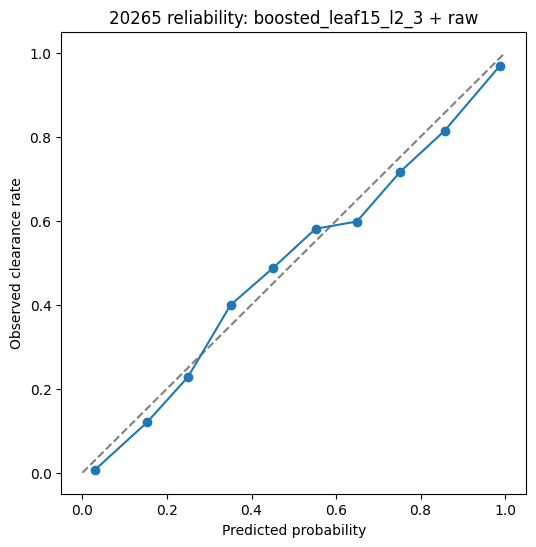

In [5]:
chosen_method = calibration_summary.index[0]
recent = session_samples[VALIDATION_SESSIONS[-1]].copy()
recent['probability'] = recent_predictions[chosen_method]
recent['ratio_band'] = pd.cut(recent['position_to_capacity'], [-np.inf, .05, .10, .20, .30, np.inf])
recent['days_band'] = pd.cut(recent['days_to_deadline'], [-np.inf, 7, 14, 30, 60, np.inf])
recent['probability_band'] = pd.cut(recent['probability'], np.linspace(0, 1, 11), include_lowest=True)

def slice_table(column):
    rows = []
    for label, group in recent.groupby(column, observed=True):
        if len(group) < 100:
            continue
        weight = group['model_weight'].to_numpy()
        predicted = np.average(group['probability'], weights=weight)
        observed = np.average(group['cleared'], weights=weight)
        rows.append({
            column: label, 'rows': len(group), 'predicted': predicted,
            'observed': observed, 'absolute_gap': abs(predicted - observed),
            'brier': brier_score_loss(group['cleared'], group['probability'], sample_weight=weight),
        })
    return pd.DataFrame(rows)

for column in ['probability_band', 'ratio_band', 'days_band', 'campus', 'term']:
    print(column)
    display(slice_table(column))

reliability = slice_table('probability_band')
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], '--', color='gray')
ax.plot(reliability['predicted'], reliability['observed'], marker='o')
ax.set(
    xlabel='Predicted probability', ylabel='Observed clearance rate',
    title=f'{VALIDATION_SESSIONS[-1]} reliability: {chosen_candidate} + {chosen_method}',
)
plt.show()

## 5. Findings and decision

All tuning and calibration comparisons used chronological holdouts and identical deterministic training rows within each fold.

### Tree tuning

- `boosted_leaf15_l2_3` had the best four-fold mean Brier at **0.05029**, with **0.01627 mean ECE** and **0.94443 mean ROC AUC**.
- The boosted configurations were tightly grouped. Mean Brier ranged only from **0.05029** to **0.05038**, so the result does not support a large or fragile tree-complexity claim.
- `boosted_leaf31_l2_1` had the best worst-fold Brier at **0.05497**, with a nearly identical **0.05030 mean Brier**.
- The logistic control remained materially behind at **0.05578 mean Brier**.

### Calibration

- Raw probabilities were best overall at **0.05024 mean Brier**, **0.01592 mean ECE**, and **0.94415 mean ROC AUC**.
- Platt and isotonic calibration improved the newest `20265` fold, but both worsened the earlier folds and the four-fold average.
- No global calibrator is selected. The production candidate should retain raw boosted-tree probabilities.

### Remaining failure slices

- Within seven days of the deadline, the model predicted **53.3%** while **38.0%** met the target, a **15.3-point overprediction**.
- Ranks above 30% of capacity were underpredicted by **2.9 points**.
- Winter offerings were overpredicted by **4.9 points**, and Scarborough offerings by **3.9 points**.
- Probability-band gaps were mixed in direction and reached a maximum of **5.1 points**.

### Decision

Carry `boosted_leaf15_l2_3` with raw probabilities into Notebook 5. Notebook 5 should test targeted deadline, rank, term, and campus features against this unchanged control. It should retain a new feature only when it improves chronological Brier and the relevant failure slice without damaging calibration elsewhere.